# Layer 0 — Exploratory Data Analysis
**Dataset:** WiDS Datathon 2020 — ICU In-Hospital Mortality Prediction

The goal of this notebook is to understand the data before building any model.
Key questions:
- How many rows and features do we have?
- What is the target variable and how is it distributed?
- What are the feature types?
- How much missing data is there?



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (12, 5)


In [2]:
df = pd.read_csv('../data/raw/training_v2.csv')
dictionary = pd.read_csv('../data/raw/WiDS Datathon 2020 Dictionary.csv')

print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')


Rows    : 91,713
Columns : 186


In [3]:
df.head()

,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,hospital_admit_source,icu_admit_source,icu_id,icu_stay_type,icu_type,pre_icu_los_days,readmission_status,weight,albumin_apache,apache_2_diagnosis,apache_3j_diagnosis,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,paco2_for_ph_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,d1_diasbp_invasive_max,d1_diasbp_invasive_min,d1_diasbp_max,d1_diasbp_min,...,h1_creatinine_max,h1_creatinine_min,h1_glucose_max,h1_glucose_min,h1_hco3_max,h1_hco3_min,h1_hemaglobin_max,h1_hemaglobin_min,h1_hematocrit_max,h1_hematocrit_min,h1_inr_max,h1_inr_min,h1_lactate_max,h1_lactate_min,h1_platelets_max,h1_platelets_min,h1_potassium_max,h1_potassium_min,h1_sodium_max,h1_sodium_min,h1_wbc_max,h1_wbc_min,d1_arterial_pco2_max,d1_arterial_pco2_min,d1_arterial_ph_max,d1_arterial_ph_min,d1_arterial_po2_max,d1_arterial_po2_min,d1_pao2fio2ratio_max,d1_pao2fio2ratio_min,h1_arterial_pco2_max,h1_arterial_pco2_min,h1_arterial_ph_max,h1_arterial_ph_min,h1_arterial_po2_max,h1_arterial_po2_min,h1_pao2fio2ratio_max,h1_pao2fio2ratio_min,apache_4a_hospital_death_prob,apache_4a_icu_death_prob,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,66154,25312,118,0,68.0,22.73,0,Caucasian,M,180.3,Floor,Floor,92,admit,CTICU,0.541667,0,73.9,2.3,113.0,502.01,0,0.0,0.4,31.0,2.51,NaN,3.0,6.0,0.0,4.0,168.0,118.0,27.4,0.0,40.0,NaN,NaN,NaN,NaN,36.0,134.0,39.3,NaN,0.0,14.1,46.0,32.0,68.0,37.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.10,0.05,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,114252,59342,81,0,77.0,27.42,0,Caucasian,F,160.0,Floor,Floor,90,admit,Med-Surg ICU,0.927778,0,70.2,NaN,108.0,203.01,0,0.0,NaN,9.0,0.56,1.0,1.0,3.0,0.0,1.0,145.0,120.0,36.9,0.0,46.0,37.0,37.0,51.0,7.45,33.0,145.0,35.1,NaN,1.0,12.7,NaN,NaN,95.0,31.0,...,0.56,0.56,145.0,143.0,27.0,27.0,11.3,11.3,36.9,36.9,1.3,1.3,3.5,3.5,557.0,557.0,4.2,4.2,145.0,145.0,12.7,12.7,37.0,37.0,7.45,7.45,51.0,51.0,54.8,51.000000,37.0,37.0,7.45,7.45,51.0,51.0,51.0,51.0,0.47,0.29,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory
2,119783,50777,118,0,25.0,31.95,0,Caucasian,F,172.7,Emergency Department,Accident & Emergency,93,admit,Med-Surg ICU,0.000694,0,95.3,NaN,122.0,703.03,0,0.0,NaN,NaN,NaN,NaN,3.0,6.0,0.0,5.0,NaN,102.0,NaN,0.0,68.0,NaN,NaN,NaN,NaN,37.0,NaN,36.7,NaN,0.0,NaN,NaN,NaN,88.0,48.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic
3,79267,46918,118,0,81.0,22.64,1,Caucasian,F,165.1,Operating Room,Operating Room / Recovery,92,admit,CTICU,0.000694,0,61.7,NaN,203.0,1206.03,1,0.0,NaN,NaN,NaN,0.6,4.0,6.0,0.0,5.0,185.0,114.0,25.9,1.0,60.0,30.0,30.0,142.0,7.39,4.0,NaN,34.8,NaN,1.0,8.0,62.0,30.0,48.0,42.0,...,NaN,NaN,NaN,NaN,NaN,NaN,11.6,11.6,34.0,34.0,1.6,1.1,NaN,NaN,43.0,43.0,NaN,NaN,NaN,NaN,8.8,8.8,37.0,27.0,7.44,7.34,337.0,102.0,342.5,236.666667,36.0,33.0,7.37,7.34,337.0,265.0,337.0,337.0,0.04,0.03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular
4,92056,34377,33,0,19.0,NaN,0,Caucasian,M,188.0,NaN,Accident & Emergency,91,admit,Med-Surg ICU,0.073611,0,NaN,NaN,119.0,601.01,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.0,NaN,0.0,103.0,NaN,NaN,NaN,NaN,16.0,NaN,36.7,NaN,0.0,NaN,NaN,NaN,99.0,57.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [4]:
df.dtypes.value_counts()

float64    170
int64        8
object       8
Name: count, dtype: int64

## Target Variable — hospital_death


In [5]:
target = 'hospital_death'

counts = df[target].value_counts()
pct = df[target].value_counts(normalize=True) * 100

print(pd.DataFrame({'count': counts, 'percent': pct.round(2)}))


                count  percent
hospital_death                
0               83798    91.37
1                7915     8.63


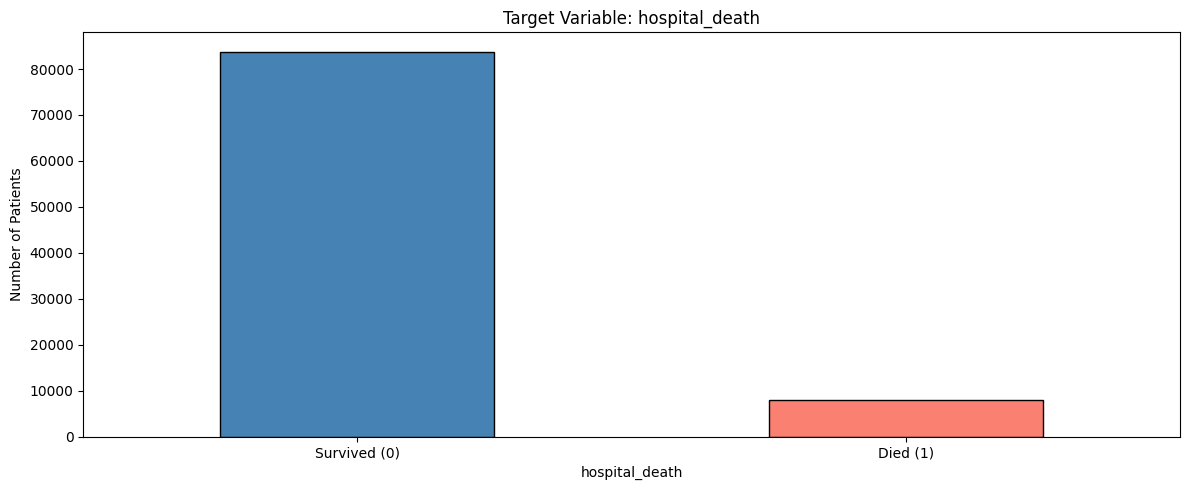

In [6]:
counts.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Target Variable: hospital_death')
plt.xticks([0, 1], ['Survived (0)', 'Died (1)'], rotation=0)
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()


## Missing Data Analysis


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

print(f'Columns with missing data : {len(missing_df)} / {df.shape[1]}')
print(f'\nTop 20:')
missing_df.head(20)


Columns with missing data : 175 / 186

Top 20:


,missing_count,missing_pct
h1_bilirubin_max,84619,92.27
h1_bilirubin_min,84619,92.27
h1_lactate_min,84369,91.99
h1_lactate_max,84369,91.99
h1_albumin_max,83824,91.40
h1_albumin_min,83824,91.40
h1_pao2fio2ratio_min,80195,87.44
h1_pao2fio2ratio_max,80195,87.44
h1_arterial_ph_min,76424,83.33
h1_arterial_ph_max,76424,83.33


In [8]:
thresholds = [50, 70, 90]
for t in thresholds:
    n = (missing_df['missing_pct'] > t).sum()
    print(f'> {t}% missing : {n} columns')


> 50% missing : 74 columns
> 70% missing : 55 columns
> 90% missing : 6 columns


## Categorical Features


In [9]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {len(cat_cols)}\n')
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} unique values → {df[col].unique()[:5]}')


Categorical columns: 8

ethnicity: 6 unique values → ['Caucasian' nan 'Hispanic' 'African American' 'Asian']
gender: 2 unique values → ['M' 'F' nan]
hospital_admit_source: 15 unique values → ['Floor' 'Emergency Department' 'Operating Room' nan 'Direct Admit']
icu_admit_source: 5 unique values → ['Floor' 'Accident & Emergency' 'Operating Room / Recovery'
 'Other Hospital' 'Other ICU']
icu_stay_type: 3 unique values → ['admit' 'readmit' 'transfer']
icu_type: 8 unique values → ['CTICU' 'Med-Surg ICU' 'CCU-CTICU' 'Neuro ICU' 'MICU']
apache_3j_bodysystem: 11 unique values → ['Sepsis' 'Respiratory' 'Metabolic' 'Cardiovascular' 'Trauma']
apache_2_bodysystem: 10 unique values → ['Cardiovascular' 'Respiratory' 'Metabolic' 'Trauma' 'Neurologic']


## Data Dictionary


In [10]:
print(dictionary.columns.tolist())
dictionary.head(10)


['Category', 'Variable Name', 'Unit of Measure', 'Data Type', 'Description', 'Example']


,Category,Variable Name,Unit of Measure,Data Type,Description,Example
0,identifier,encounter_id,NaN,integer,Unique identifier associated with a patient un...,NaN
1,identifier,hospital_id,NaN,integer,Unique identifier associated with a hospital,NaN
2,identifier,patient_id,NaN,integer,Unique identifier associated with a patient,NaN
3,demographic,hospital_death,NaN,binary,Whether the patient died during this hospitali...,0
4,demographic,age,Years,numeric,The age of the patient on unit admission,NaN
5,demographic,bmi,kilograms/metres^2,string,The body mass index of the person on unit admi...,21.5
6,demographic,elective_surgery,NaN,binary,Whether the patient was admitted to the hospit...,0
7,demographic,ethnicity,NaN,string,The common national or cultural tradition whic...,Caucasian
8,demographic,gender,NaN,string,The genotypical sex of the patient,F
9,demographic,height,centimetres,numeric,The height of the person on unit admission,180


## Feature Groups


In [11]:
all_cols = [c for c in df.columns if c != 'hospital_death']

groups = {
    'identifier'  : [c for c in all_cols if c in ['encounter_id', 'patient_id', 'hospital_id']],
    'demographic' : [c for c in all_cols if c in ['age', 'bmi', 'height', 'weight', 'gender', 'ethnicity', 'elective_surgery']],
    'apache'      : [c for c in all_cols if 'apache' in c],
    'h1_lab'      : [c for c in all_cols if c.startswith('h1_')],
    'd1_lab'      : [c for c in all_cols if c.startswith('d1_')],
    'icu_info'    : [c for c in all_cols if 'icu' in c],
    'vitals'      : [c for c in all_cols if any(x in c for x in ['heart_rate', 'temp', 'glucose', 'sodium', 'map_'])],
}

for group, cols in groups.items():
    print(f'{group:15s} → {len(cols):3d} columns')

identifier      →   3 columns
demographic     →   7 columns
apache          →  32 columns
h1_lab          →  64 columns
d1_lab          →  64 columns
icu_info        →   6 columns
vitals          →  17 columns


## Numeric Feature Distributions


In [12]:
key_features = ['age', 'bmi', 'heart_rate_apache', 'temp_apache',
                 'map_apache', 'glucose_apache', 'sodium_apache',
                 'creatinine_apache', 'bun_apache']

df[key_features].describe().round(2)


,age,bmi,heart_rate_apache,temp_apache,map_apache,glucose_apache,sodium_apache,creatinine_apache,bun_apache
count,87485.00,88284.00,90835.00,87605.00,90719.00,80677.00,73113.00,72860.00,72451.00
mean,62.31,29.19,99.71,36.41,88.02,160.33,137.97,1.48,25.83
std,16.78,8.28,30.87,0.83,42.03,90.79,5.28,1.53,20.67
min,16.00,14.84,30.00,32.10,40.00,39.00,117.00,0.30,4.00
25%,52.00,23.64,86.00,36.20,54.00,97.00,135.00,0.72,13.00
50%,65.00,27.65,104.00,36.50,67.00,133.00,138.00,0.98,19.00
75%,75.00,32.93,120.00,36.70,125.00,196.00,141.00,1.53,32.00
max,89.00,67.81,178.00,39.70,200.00,598.70,158.00,11.18,127.00


In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'hospital_death']

corr = df[numeric_cols].corrwith(df['hospital_death']).abs().sort_values(ascending=False)

print('Top 20 features correlated with hospital_death:\n')
print(corr.head(20).round(3))


Top 20 features correlated with hospital_death:

d1_lactate_min                   0.404
d1_lactate_max                   0.399
h1_lactate_min                   0.344
h1_lactate_max                   0.341
apache_4a_hospital_death_prob    0.311
apache_4a_icu_death_prob         0.284
gcs_motor_apache                 0.282
gcs_eyes_apache                  0.260
gcs_verbal_apache                0.241
d1_sysbp_invasive_min            0.234
d1_arterial_ph_min               0.230
ventilated_apache                0.229
h1_albumin_min                   0.225
h1_albumin_max                   0.225
d1_mbp_invasive_min              0.222
fio2_apache                      0.212
d1_sysbp_min                     0.210
d1_spo2_min                      0.210
d1_sysbp_noninvasive_min         0.210
h1_arterial_ph_max               0.208
dtype: float64


/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [14]:
duplicate_rows = df.duplicated().sum()
duplicate_patients = df['patient_id'].duplicated().sum()

print(f'Duplicate rows    : {duplicate_rows}')
print(f'Duplicate patients: {duplicate_patients}')


Duplicate rows    : 0
Duplicate patients: 0


## Feature Distributions by Target


/var/folders/8q/6ppn3sn52s37836ffh2298v40000gn/T/ipykernel_92536/2898667367.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([survived, died], labels=['Survived', 'Died'], patch_artist=True,
/var/folders/8q/6ppn3sn52s37836ffh2298v40000gn/T/ipykernel_92536/2898667367.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([survived, died], labels=['Survived', 'Died'], patch_artist=True,
/var/folders/8q/6ppn3sn52s37836ffh2298v40000gn/T/ipykernel_92536/2898667367.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([survived, died], labels=['Survived', 'Died'], patch_artis

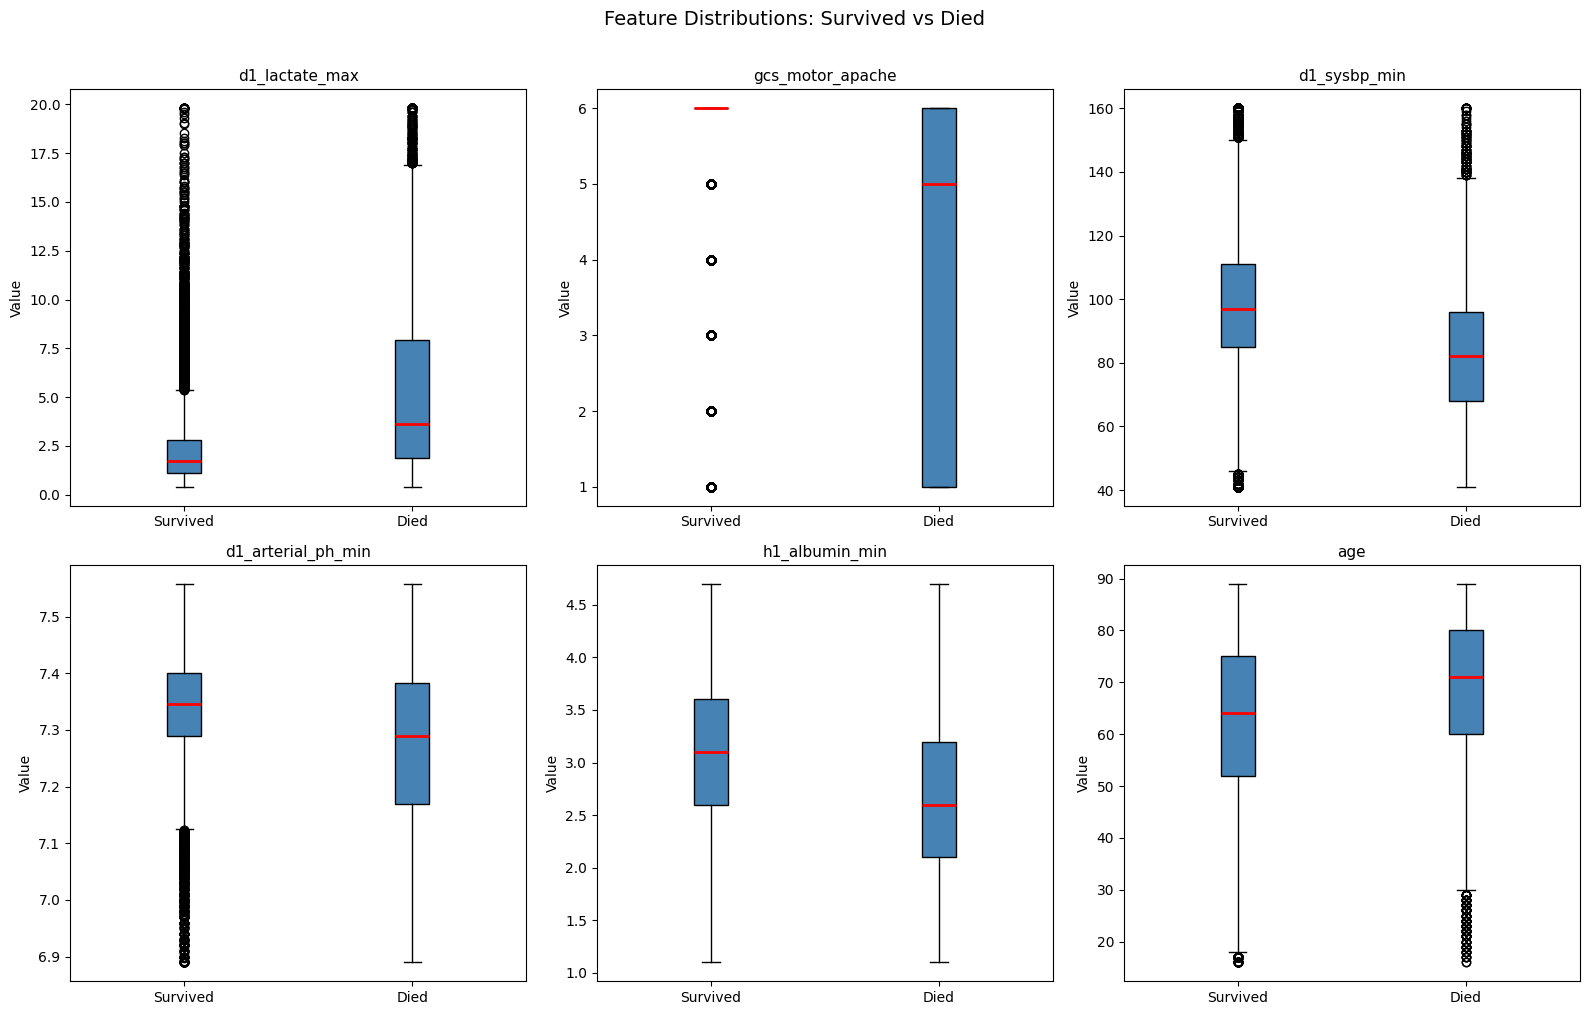

In [15]:
features_to_plot = [
    'd1_lactate_max', 'gcs_motor_apache', 'd1_sysbp_min',
    'd1_arterial_ph_min', 'h1_albumin_min', 'age'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    survived = df[df['hospital_death'] == 0][feature].dropna()
    died     = df[df['hospital_death'] == 1][feature].dropna()

    axes[i].boxplot([survived, died], labels=['Survived', 'Died'], patch_artist=True,
                    boxprops=dict(facecolor='steelblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feature, fontsize=11)
    axes[i].set_ylabel('Value')

plt.suptitle('Feature Distributions: Survived vs Died', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## APACHE Leakage Investigation


In [16]:
leakage_cols = ['apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob']

print('=== Basic Stats ===')
print(df[leakage_cols].describe().round(3))

print('\n=== Missing Data ===')
for col in leakage_cols:
    missing = df[col].isnull().sum()
    print(f'{col}: {missing} missing ({missing/len(df)*100:.1f}%)')

print('\n=== Mean by target ===')
print(df.groupby('hospital_death')[leakage_cols].mean().round(3))


=== Basic Stats ===
       apache_4a_hospital_death_prob  apache_4a_icu_death_prob
count                      83766.000                 83766.000
mean                           0.087                     0.044
std                            0.248                     0.217
min                           -1.000                    -1.000
25%                            0.020                     0.010
50%                            0.050                     0.020
75%                            0.130                     0.060
max                            0.990                     0.970

=== Missing Data ===
apache_4a_hospital_death_prob: 7947 missing (8.7%)
apache_4a_icu_death_prob: 7947 missing (8.7%)

=== Mean by target ===
                apache_4a_hospital_death_prob  apache_4a_icu_death_prob
hospital_death                                                         
0                                       0.063                     0.025
1                                       0.335         

## Missingness vs Target


In [17]:
key_cols = ['d1_lactate_max', 'h1_albumin_min', 'd1_arterial_ph_min',
            'h1_bilirubin_max', 'd1_sysbp_min', 'creatinine_apache']

print(f'{"Feature":<30} {"Missing(Survived)%":>20} {"Missing(Died)%":>15}')
print('-' * 67)

for col in key_cols:
    surv_missing = df[df['hospital_death']==0][col].isnull().mean() * 100
    died_missing = df[df['hospital_death']==1][col].isnull().mean() * 100
    print(f'{col:<30} {surv_missing:>19.1f}% {died_missing:>14.1f}%')


Feature                          Missing(Survived)%  Missing(Died)%
-------------------------------------------------------------------
d1_lactate_max                                77.0%           49.2%
h1_albumin_min                                91.9%           85.8%
d1_arterial_ph_min                            68.4%           35.1%
h1_bilirubin_max                              92.7%           87.2%
d1_sysbp_min                                   0.2%            0.4%
creatinine_apache                             20.8%           18.3%


## Mortality Rate by Categorical Features


In [22]:
for col in cat_cols:
    result = (df.groupby(col)['hospital_death']
                .agg(['count', 'mean'])
                .rename(columns={'count': 'n_patients', 'mean': 'mortality_rate'})
                .sort_values('mortality_rate', ascending=False))
    result['mortality_rate'] = (result['mortality_rate'] * 100).round(1)
    display(result)



,n_patients,mortality_rate
ethnicity,,
Hispanic,3796,9.9
Native American,788,8.9
Caucasian,70684,8.7
Asian,1129,8.2
Other/Unknown,4374,8.1
African American,9547,7.9


,n_patients,mortality_rate
gender,,
F,42219,8.8
M,49469,8.4


,n_patients,mortality_rate
hospital_admit_source,,
Step-Down Unit (SDU),1131,18.8
Other ICU,233,15.0
Other,7,14.3
Floor,8055,13.9
Other Hospital,1641,13.5
Acute Care/Floor,1910,10.5
Direct Admit,6441,10.3
Emergency Department,36962,8.7
ICU,35,8.6


,n_patients,mortality_rate
icu_admit_source,,
Other ICU,859,14.4
Other Hospital,2358,13.4
Floor,15611,13.4
Accident & Emergency,54060,8.6
Operating Room / Recovery,18713,3.7


,n_patients,mortality_rate
icu_stay_type,,
transfer,4970,10.6
readmit,560,8.9
admit,86183,8.5


,n_patients,mortality_rate
icu_type,,
MICU,7695,12.1
Cardiac ICU,4776,10.3
Med-Surg ICU,50586,8.7
Neuro ICU,7675,8.3
CCU-CTICU,7156,7.6
SICU,5209,7.5
CTICU,4003,6.0
CSICU,4613,5.5


,n_patients,mortality_rate
apache_3j_bodysystem,,
Sepsis,11740,15.8
Respiratory,11609,11.2
Hematological,638,9.1
Cardiovascular,29999,8.0
Neurological,11896,7.9
Gastrointestinal,9026,7.4
Trauma,3842,6.7
Genitourinary,2172,6.2
Musculoskeletal/Skin,1166,4.7


,n_patients,mortality_rate
apache_2_bodysystem,,
Respiratory,11609,11.2
Cardiovascular,38816,10.8
Haematologic,638,9.1
Neurologic,11896,7.9
Gastrointestinal,9026,7.4
Trauma,3842,6.7
Renal/Genitourinary,2460,5.5
Undefined Diagnoses,346,5.2
Undefined diagnoses,3768,2.0


## Outlier Analysis — Numerical Features


In [24]:
outlier_features = ['age', 'bmi', 'heart_rate_apache', 'temp_apache',
                    'map_apache', 'glucose_apache', 'creatinine_apache', 'bun_apache']

print(f'{"Feature":<25} {"Min":>8} {"Max":>8} {"Mean":>8} {"Std":>8}')
print('-' * 65)

for col in outlier_features:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    pct = outliers / df[col].notna().sum() * 100
    print(f'{col:<25} {df[col].min():>8.1f} {df[col].max():>8.1f} {df[col].mean():>8.1f} {pct:>7.1f}%')


Feature                        Min      Max     Mean      Std
-----------------------------------------------------------------
age                           16.0     89.0     62.3     0.2%
bmi                           14.8     67.8     29.2     3.7%
heart_rate_apache             30.0    178.0     99.7     1.8%
temp_apache                   32.1     39.7     36.4    10.0%
map_apache                    40.0    200.0     88.0     0.0%
glucose_apache                39.0    598.7    160.3     4.8%
creatinine_apache              0.3     11.2      1.5    10.3%
bun_apache                     4.0    127.0     25.8     7.1%


## EDA Summary

| Finding | Detail |
|---------|--------|
| Dataset | 91,713 patients, 186 columns |
| Target | hospital_death — 8.6% positive (imbalanced) |
| Missing data | 175/186 columns, 74 columns >50% missing |
| Strongest signals | lactate, GCS, blood pressure, pH, albumin |
| Leakage columns | apache_4a_hospital_death_prob, apache_4a_icu_death_prob — to be dropped |
| Missingness pattern | Died group has less missing data in key labs — missingness is informative |
| Highest mortality | Sepsis (15.8%), Step-Down Unit admits (18.8%), MICU (12.1%) |
| Outliers | Clinically meaningful — do not remove |
| Duplicates | None |
| Key metric | Use AUC-ROC, not accuracy |
